In [178]:
import openai
import pandas as pd
from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import VectorParams, Filter, FieldCondition, MatchValue, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

from IPython.display import Image, display
from typing import Literal, Any, Annotated, List, Dict
import random
from operator import add
from jinja2 import Template
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode
from langgraph.types import Send
import instructor
from langsmith import traceable, get_current_run_tree

In [ ]:
qdrant_collection_name="Amazon-shopping-collection-01-hybrid-search"
qdrant_client = QdrantClient(url="http://localhost:6333")

In [ ]:
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(input=text, model="text-embedding-3-small")
    return response.data[0].embedding

In [ ]:
def retrieve_data(query, qdrant_client, k=5, hybrid=True):

    query_embedding = get_embedding(query)
    
    if hybrid:
        # Sprint 1 : lesson 5 - Weighted RRF
        results = qdrant_client.query_points(
            collection_name=qdrant_collection_name, 
            prefetch = [
                Prefetch(query = query_embedding, using = "text-embedding-3-small", limit = 20),
                Prefetch(query = Document(text=query, model = "qdrant/bm25"), using = "bm25", limit = 20)
            ],
            query=models.RrfQuery(rrf = models.Rrf(weights=[3,1])),
            limit=k)
    else:
         # Sprint 1 : lesson 5 - Weighted RRF
        results = qdrant_client.query_points(
            collection_name=qdrant_collection_name, 
            query = query_embedding,
            using = "text-embedding-3-small",
            limit=k)

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for pts in results.points:
        retrieved_context_ids.append(pts.payload['parent_asin'])
        retrieved_context.append(pts.payload['preprocessed_description'])
        similarity_scores.append(pts.score)
        retrieved_context_ratings.append(pts.payload['average_rating'])
        
    return {
        'retrieved_context_ids': retrieved_context_ids,
        'retrieved_context': retrieved_context,
        'similarity_scores': similarity_scores,
        'retrieved_context_ratings': retrieved_context_ratings
    }

In [ ]:
def process_context(context):
    formated_context = ""
    for id, chunk, rating in zip(context['retrieved_context_ids'], context['retrieved_context'], context['retrieved_context_ratings']):
        formated_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"
    return formated_context

In [ ]:
query ="Do you wirless bluetooth earphones?" 
answer = retrieve_data(query, qdrant_client, k =10)
answer

In [ ]:
query = "do you have iphone, ipad, wireless charger?"
answer = retrieve_data(query, qdrant_client, k =10)
answer

In [ ]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [ ]:
def query_expansion_node(query: str) -> dict:
    prompt = """
    You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

    ## Instructions

    - Expand the question into 1-5 concise statements.
    - Each statement should capture a separate product or attribute from the query.
    - Use natural product-description language.
    - Do not produce multiple statements that express the same intent.

    ## Examples

    Question: "Can I get earphones for me and a waterproof speaker?"
    Statements:
    - "Personal earphones"
    - "Waterproof speaker"

    Question: "I need a warm winter jacket for hiking"
    Statements:
    - "Insulated winter jacket"
    - "Hiking outerwear for cold weather"

    Question: "Do you have any toys?"
    Statements:
    - "Toys"

    <question>
    {{ query }}
    </question>
    """

    jinja_template = Template(prompt)
    rendered_template = jinja_template.render(query = query)
    client = instructor.from_provider("openai/gpt-5.4-nano", mode=instructor.Mode.RESPONSES_TOOLS)
    response = client.create(messages=[{"role": "system", "content": rendered_template}], 
                                reasoning={"effort": "none"},
                                response_model=QueryExpandResponse
                                )
    return {
        "queries": response.statements
    }



In [ ]:
answer = query_expansion_node("do you have iphone, ipad, wireless charger?")
answer

## LangGraph

### Query Expansion(Sequential Execution)

In [ ]:
class State(BaseModel):
    expanded_query: List[str] = []
    retreived_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str =""

In [ ]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [108]:
@traceable(name = "query_expansion", run_type = "llm", metadata= {"ls_provider":"openai", "ls_model_name":"gpt-5.4-mini"})
def query_expansion_node(state: State) -> dict:
    prompt = """
    You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

    ## Instructions

    - Expand the question into 1-5 concise statements.
    - Each statement should capture a separate product or attribute from the query.
    - Use natural product-description language.
    - Do not produce multiple statements that express the same intent.

    ## Examples

    Question: "Can I get earphones for me and a waterproof speaker?"
    Statements:
    - "Personal earphones"
    - "Waterproof speaker"

    Question: "I need a warm winter jacket for hiking"
    Statements:
    - "Insulated winter jacket"
    - "Hiking outerwear for cold weather"

    Question: "Do you have any toys?"
    Statements:
    - "Toys"

    <question>
    {{ query }}
    </question>
    """

    jinja_template = Template(prompt)
    rendered_template = jinja_template.render(query = state.initial_query)
    client = instructor.from_provider("openai/gpt-5.4-mini", mode=instructor.Mode.RESPONSES_TOOLS)
    response = client.create(messages=[{"role": "system", "content": rendered_template}], 
                                reasoning={"effort": "none"},
                                response_model=QueryExpandResponse
                                )
    print(f"query_expansion_node: {response.statements}")
    return {
        "expanded_query": response.statements
    }



### Retriever Node

In [ ]:
@traceable(name = "get_embedding", run_type = "embedding",metadata= {"ls_model_provider": "openai","ls_model_name": "text-embedding-3-small"})
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(input=text, model="text-embedding-3-small")
    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"]={
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens
        }
    return response.data[0].embedding
#--------------------------------------------------------------
@traceable( name = "retrieve_data" , run_type="retriever")
def retrieve_data(query, qdrant_client, k=5, hybrid=True):
    print(f"start retrieve_data")
    query_embedding = get_embedding(query)
    print(f"retrieve_data/query_embedding: {query_embedding}")
    if hybrid:
        # Sprint 1 : lesson 5 - Weighted RRF
        results = qdrant_client.query_points(
            collection_name=qdrant_collection_name, 
            prefetch = [
                Prefetch(query = query_embedding, using = "text-embedding-3-small", limit = 20),
                Prefetch(query = Document(text=query, model = "qdrant/bm25"), using = "bm25", limit = 20)
            ],
            query=models.RrfQuery(rrf = models.Rrf(weights=[3,1])),
            limit=k)
    else:
         # Sprint 1 : lesson 5 - Weighted RRF
        results = qdrant_client.query_points(
            collection_name=qdrant_collection_name, 
            query = query_embedding,
            using = "text-embedding-3-small",
            limit=k)
    print(f"retrieve_data/results: {results}")
    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for pts in results.points:
        retrieved_context_ids.append(pts.payload['parent_asin'])
        retrieved_context.append(pts.payload['preprocessed_description'])
        similarity_scores.append(pts.score)
        retrieved_context_ratings.append(pts.payload['average_rating'])

    print(f"retrieve_data/pts")

    formated_context = ""
    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formated_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"
    print(f"retrieve_data: {formated_context}")
    return formated_context

In [ ]:
@traceable(name="retriever_node", run_type="retriever")
def retriever_node(state: State) -> dict:
    qdrant_client = QdrantClient(url="http://localhost:6333")
    retreived_context = []
    for query in state.expanded_query:
        retreived_context.append(retrieve_data(query, qdrant_client, k=5))
    return {"retreived_context":retreived_context}

### Aggregator Node

In [ ]:
class AggregatorResponse(BaseModel):
    answer: str


In [ ]:
@traceable(name = "generate_answer", run_type = "llm", metadata= {"ls_provider":"openai", "ls_model_name":"gpt-5.4-mini"})
def aggregator_node(state: State) -> dict:
    preprocessed_context = "\n".join(state.retreived_context)
    
    prompt_template = """
    You are a shopping assistant that can answer questions about the products in stock.

    You will be given a question and a list of context.

    ### Instructions

    - You need to answer the question based on the provided context only.
    - Never use word context and refer to it as the available products.
    - The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

    ### Context

    {{ preprocessed_context }}

    ### Question

    {{ question }}
"""

    jinja_template = Template(prompt_template)
    rendered_template = jinja_template.render(preprocessed_context = preprocessed_context, question = state.initial_query)
    client = instructor.from_provider("openai/gpt-5.4-mini", mode=instructor.Mode.RESPONSES_TOOLS)
    response = client.create(messages=[{"role": "system", "content": rendered_template}], 
                                reasoning={"effort": "none"},
                                response_model=AggregatorResponse
                                )
    return {
        "answer": response.answer
    }

In [ ]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("query_expansion_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
initial_state = {
    "initial_query": "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"
}

In [ ]:
result = graph.invoke(initial_state)
result

In [ ]:
print(result["answer"])

## Parallel Execution

In [144]:
class State(BaseModel):
    expanded_query: List[str] = []
    retreived_context: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str =""
    query: str = ""
    k: int = 10

In [145]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [146]:
@traceable(name = "query_expansion", run_type = "llm", metadata= {"ls_provider":"openai", "ls_model_name":"gpt-5.4-mini"})
def query_expansion_node(state: State) -> dict:
    prompt = """
    You are a query expansion module in a shopping assistant. Your job is to rewrite a customer's query into distinct statements for semantic product search.

    ## Instructions

    - Expand the question into 1-5 concise statements.
    - Each statement should capture a separate product or attribute from the query.
    - Use natural product-description language.
    - Do not produce multiple statements that express the same intent.

    ## Examples

    Question: "Can I get earphones for me and a waterproof speaker?"
    Statements:
    - "Personal earphones"
    - "Waterproof speaker"

    Question: "I need a warm winter jacket for hiking"
    Statements:
    - "Insulated winter jacket"
    - "Hiking outerwear for cold weather"

    Question: "Do you have any toys?"
    Statements:
    - "Toys"

    <question>
    {{ query }}
    </question>
    """

    jinja_template = Template(prompt)
    rendered_template = jinja_template.render(query = state.initial_query)
    client = instructor.from_provider("openai/gpt-5.4-mini", mode=instructor.Mode.RESPONSES_TOOLS)
    response = client.create(messages=[{"role": "system", "content": rendered_template}], 
                                reasoning={"effort": "none"},
                                response_model=QueryExpandResponse
                                )
    print(f"query_expansion_node: {response.statements}")
    return {
        "expanded_query": response.statements
    }



In [165]:
def query_expand_conditional_edges(state: State) -> dict:
    print(f"start send_message")
    send_messages = []
    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": state.k
                }
            )
        )
    print(f"send_messages: {send_messages}")
    return send_messages

In [151]:
@traceable(name = "get_embedding", run_type = "embedding",metadata= {"ls_model_provider": "openai","ls_model_name": "text-embedding-3-small"})
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(input=text, model="text-embedding-3-small")
    current_run = get_current_run_tree()
    if current_run:
        current_run.metadata["usage_metadata"]={
            "input_tokens": response.usage.prompt_tokens,
            "total_tokens": response.usage.total_tokens
        }
    return response.data[0].embedding

In [191]:
@traceable( name = "retrieve_data" , run_type="retriever")
def retriever_node(state: State) -> dict:
    print("after 0000000000000000")
    qdrant_client = QdrantClient(url="http://localhost:6333")
    hybrid = True
    query_embedding = get_embedding(state["query"])
    print("after embedding")
    if hybrid:
        # Sprint 1 : lesson 5 - Weighted RRF
        results = qdrant_client.query_points(
            collection_name=qdrant_collection_name, 
            prefetch = [
                Prefetch(query = query_embedding, using = "text-embedding-3-small", limit = 20),
                Prefetch(query = Document(text=query, model = "qdrant/bm25"), using = "bm25", limit = 20)
            ],
            query=models.RrfQuery(rrf = models.Rrf(weights=[3,1])),
            limit=state["k"])
    else:
         # Sprint 1 : lesson 5 - Weighted RRF
        results = qdrant_client.query_points(
            collection_name=qdrant_collection_name, 
            query = query_embedding,
            using = "text-embedding-3-small",
            limit=state["k"])
    print("after 22222222222")
    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []
    print("after 333333333333")
    for pts in results.points:
        retrieved_context_ids.append(pts.payload['parent_asin'])
        retrieved_context.append(pts.payload['preprocessed_description'])
        similarity_scores.append(pts.score)
        retrieved_context_ratings.append(pts.payload['average_rating'])
    print("after 444444444444444")
    formated_context = ""
    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formated_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"
    print(f"retrieve_data: {formated_context}")
    return {
        "retreived_context" : [formated_context]
    }

In [129]:
class AggregatorResponse(BaseModel):
    answer: str


In [130]:
@traceable(name = "generate_answer", run_type = "llm", metadata= {"ls_provider":"openai", "ls_model_name":"gpt-5.4-mini"})
def aggregator_node(state: State) -> dict:
    preprocessed_context = "\n".join(state.retreived_context)
    
    prompt_template = """
    You are a shopping assistant that can answer questions about the products in stock.

    You will be given a question and a list of context.

    ### Instructions

    - You need to answer the question based on the provided context only.
    - Never use word context and refer to it as the available products.
    - The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

    ### Context

    {{ preprocessed_context }}

    ### Question

    {{ question }}
"""

    jinja_template = Template(prompt_template)
    rendered_template = jinja_template.render(preprocessed_context = preprocessed_context, question = state.initial_query)
    client = instructor.from_provider("openai/gpt-5.4-mini", mode=instructor.Mode.RESPONSES_TOOLS)
    response = client.create(messages=[{"role": "system", "content": rendered_template}], 
                                reasoning={"effort": "none"},
                                response_model=AggregatorResponse
                                )
    return {
        "answer": response.answer
    }

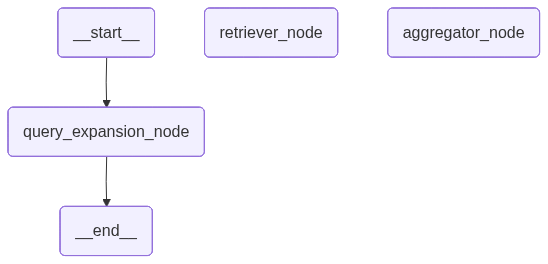

In [192]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_conditional_edges(
    "query_expansion_node", query_expand_conditional_edges
)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [132]:
initial_state = {
    "initial_query": "Can I get a tablet for my kid, a watch for me and a laptop for my wife?"
}

In [194]:
result = graph.invoke(initial_state)
result

query_expansion_node: ['Tablet for a kid', 'Watch for an adult', 'Laptop for a wife']
start send_message
send_messages: [Send(node='retriever_node', arg={'query': 'Tablet for a kid', 'k': 10}), Send(node='retriever_node', arg={'query': 'Watch for an adult', 'k': 10}), Send(node='retriever_node', arg={'query': 'Laptop for a wife', 'k': 10})]
after 0000000000000000
after 0000000000000000
after 0000000000000000
after embedding
after 22222222222
after 333333333333
after 444444444444444
retrieve_data: - ID: B09L2HVDQ8, rating: 4.7, description: Amazon Fire HD 8 Kids Pro tablet, 8" HD, ages 6–12, 32 GB, (2021 release), IntergalacticSave up to $70 on a full-featured tablet (not a toy) designed specifically for kids ages 6–12 that includes 1 year of Amazon Kids+, parental controls, a slim case, and a 2-year worry-free guarantee, versus items purchased separately. Includes 1 year of Amazon Kids+ - a digital subscription designed for kids to safely learn, grow and explore. On the Fire HD 8 Kids,

{'expanded_query': ['Tablet for a kid',
  'Watch for an adult',
  'Laptop for a wife'],
 'retreived_context': ['- ID: B09L2HVDQ8, rating: 4.7, description: Amazon Fire HD 8 Kids Pro tablet, 8" HD, ages 6–12, 32 GB, (2021 release), IntergalacticSave up to $70 on a full-featured tablet (not a toy) designed specifically for kids ages 6–12 that includes 1 year of Amazon Kids+, parental controls, a slim case, and a 2-year worry-free guarantee, versus items purchased separately. Includes 1 year of Amazon Kids+ - a digital subscription designed for kids to safely learn, grow and explore. On the Fire HD 8 Kids, kids can enjoy thousands of ad-free books, games, videos, apps and more. After 1 year, your subscription will automatically renew every month starting at just $4.99/month plus applicable tax. You may cancel any time by visiting the Amazon Parent Dashboard or contacting Customer Service. In addition to Kids+ content, Kids Pro tablets include access to a digital store. Kids can request ap